In [1]:
import pickle
import numpy as np

from src.linear_correlations import CorrelationGenerator

MAIN_SEED = 42
np.random.seed(MAIN_SEED)

## Simulate Infinite Model

In [2]:
d_in = 3
d_out = 3

N = 1

x_scale = 0.8
x_true = np.random.randn(d_in)
x_true = x_scale*(x_true/np.linalg.norm(x_true))

A_true = np.random.randn(d_out, d_in)
noise_level = 0.05
y_true = A_true @ x_true + noise_level * np.random.randn(d_out)

In [3]:
x_true, y_true, A_true

(array([ 0.48000164, -0.13361224,  0.62589632]),
 array([ 0.62789524,  0.26597976, -0.05539644]),
 array([[ 1.52302986, -0.23415337, -0.23413696],
        [ 1.57921282,  0.76743473, -0.46947439],
        [ 0.54256004, -0.46341769, -0.46572975]]))

In [4]:
K = 15
eta_0 = 0.1

In [5]:
infinite_model = CorrelationGenerator(
    x=x_true,
    y=y_true,
    sigma_u=1, 
    sigma_v=1, 
    a=1, 
    eta_u=eta_0, 
    eta_v=eta_0, 
    sigma_we=1, 
    sigma_wu=1,
    K=K,
    num_s=100
    )

In [6]:
result = infinite_model.run()

Running step 1/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 2/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 3/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 4/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 5/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running f

## Load Datapoints

In [7]:
D, L, M = 1000, 200, 1000
max_D = 1000

In [8]:
with open(f"data/exp_track_single_trajectory/W_e_maxD{max_D}_din{d_in}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f:
    rootW_e = pickle.load(f)
with open(f"data/exp_track_single_trajectory/W_u_maxD{max_D}_dout{d_out}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f:
    rootW_u = pickle.load(f)

with open(f"data/exp_track_single_trajectory/model_outputs_D{D}_L{L}_M{M}.pkl", "rb") as f: 
    model_outputs = pickle.load(f)
with open(f"data/exp_track_single_trajectory/hs_D{D}_L{L}_M{M}.pkl", "rb") as f:
    hs = pickle.load(f)
with open(f"data/exp_track_single_trajectory/bs_D{D}_L{L}_M{M}.pkl", "rb") as f:
    bs = pickle.load(f)

## Obtain trajectories and Correlations

In [9]:
h_ds = hs[:, :, 0, :].transpose(1,2,0)
b_ds = bs[:, :, 0, :].transpose(1,2,0)

In [10]:
from scipy.interpolate import interp1d
def interpolate(H_d, new_len):
    x_old = np.linspace(0, 1, H_d.shape[0])
    x_new = np.linspace(0, 1, new_len)
    f = interp1d(x_old, H_d, axis=0, kind='linear')
    return f(x_new) 

In [11]:
from src.linear_simulation import simulate_system_batched_optimized

H_ds_raw, B_ds_raw = simulate_system_batched_optimized(
    rootW_e[:D], rootW_u[:D],
    infinite_model.Gamma_H, infinite_model.Gamma_B,
    infinite_model.A, infinite_model.A_tilde,
    infinite_model.grad_loss_array, infinite_model.x,
)
H_ds = np.stack([interpolate(H_ds_raw[d], L+1) for d in range(D)])
B_ds = np.stack([interpolate(B_ds_raw[d], L+1) for d in range(D)])


In [12]:
correlationH_track = np.array([infinite_model.Gamma_H[:,j,j] for j in range(infinite_model.Gamma_H.shape[1])])
correlationB_track = np.array([infinite_model.Gamma_B[:,j,j] for j in range(infinite_model.Gamma_B.shape[1])])

correlation_H_interp = interpolate(correlationH_track.T, L+1).T 
correlation_B_interp = interpolate(correlationB_track.T, L+1).T 

std_H = np.sqrt(correlation_H_interp)
std_B = np.sqrt(correlation_B_interp)
print(f"std_H shape: {std_H.shape}")
print(f"std_B shape: {std_B.shape}")

std_H shape: (15, 201)
std_B shape: (15, 201)


In [13]:
H_ds.shape, h_ds.shape, B_ds.shape, b_ds.shape # D, L+1, K

((1000, 201, 15), (1000, 201, 15), (1000, 201, 15), (1000, 201, 15))

# Plotting Functions

In [14]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
train_iter = 3

def plot_trajectory(finite_model, infinite_model, train_iter, n_coords=10):
    fig, ax = plt.subplots()
    D = finite_model.shape[0]
    Ds = np.linspace(0, D-1, n_coords, dtype=int)

    norm = plt.Normalize(vmin=0, vmax=D)
    cmap = plt.cm.viridis
    colors = cmap(norm(Ds))

    for color, d in zip(colors, Ds):
        ax.plot(finite_model[d, :, train_iter], color=color)
        ax.plot(infinite_model[d, :, train_iter], color=color, linestyle='--')

    #ax.set_ylim(-1, 1)
    ymax = max(
        np.max(np.abs(finite_model[Ds, :, train_iter])),
        np.max(np.abs(infinite_model[Ds, :, train_iter]))
    )
    ax.set_ylim(-ymax, ymax) 
    ax.set_xlabel('Depth')
    ax.set_ylabel('Coordinate Value')
    ax.set_title(rf'Coordinate trajectory at $k={train_iter}$')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label='d')

    finite_line = mlines.Line2D([], [], color='black', linestyle='-', label='Finite ResNet')
    infinite_line = mlines.Line2D([], [], color='black', linestyle='--', label='Limit Model')
    ax.legend(handles=[finite_line, infinite_line])
    return fig

In [15]:
from scipy.stats import norm

def plot_time_slices(H_track, std_H, iteration_indices=None, time_slices=None):
    if iteration_indices is None:
        iteration_indices = [0, len(H_track)//2, -1]
    if time_slices is None:
        T = H_track.shape[-1]
        time_slices = [0, T//4, T//2, 3*T//4, T-1]
    
    fig, axes = plt.subplots(len(time_slices), len(iteration_indices), 
                            figsize=(5*len(iteration_indices), 3*len(time_slices)))
    
    if len(time_slices) == 1:
        axes = axes.reshape(1, -1)
    if len(iteration_indices) == 1:
        axes = axes.reshape(-1, 1)

    x_min, x_max = -np.max([np.abs(H_track[k, :, 0, t]) for t in time_slices for k in iteration_indices]), \
                    np.max([np.abs(H_track[k, :, 0, t]) for t in time_slices for k in iteration_indices])
    
    row_y_maxes = []
    for i, t in enumerate(time_slices):
        y_max = 0
        for j, k in enumerate(iteration_indices):
            H_data = H_track[k, :, 0, t]
            counts, bin_edges = np.histogram(H_data, bins=30, density=True)
            y_max = max(y_max, counts.max())
            if std_H is not None:
                x = np.linspace(x_min, x_max, 200)
                gaussian = norm.pdf(x, loc=0, scale=std_H[k, t])
                y_max = max(y_max, gaussian.max())
        row_y_maxes.append(y_max * 1.1) 

    for i, t in enumerate(time_slices):
        for j, k in enumerate(iteration_indices):
            ax = axes[i, j]
            H_data = H_track[k, :, 0, t]
            
            ax.hist(H_data, bins=30, density=True, alpha=0.6, 
                   color='steelblue', edgecolor='black', label='Finite ResNet')
            
            if std_H is not None:
                x = np.linspace(x_min, x_max, 200)
                gaussian = norm.pdf(x, loc=0, scale=std_H[k, t])
                ax.plot(x, gaussian, 'r-', linewidth=2, label='Limit Model')
            
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(0, row_y_maxes[i])

            ax.set_xlabel('Value', fontsize=10)
            if j == 0:
                ax.set_ylabel('Density', fontsize=10)
            if i == 0:
                ax.set_title(rf'$k={k}$', fontsize=11, fontweight='bold')
            if j == len(iteration_indices) - 1:
                ax.text(1.02, 0.5, rf'$\ell={t}$', transform=ax.transAxes,
                       rotation=270, va='center', fontsize=11, fontweight='bold')
            if i == 0 and j == 0:
                ax.legend(loc='upper right', fontsize=8)
            
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plots

In [16]:
plot_k = 8

### Forward Pass

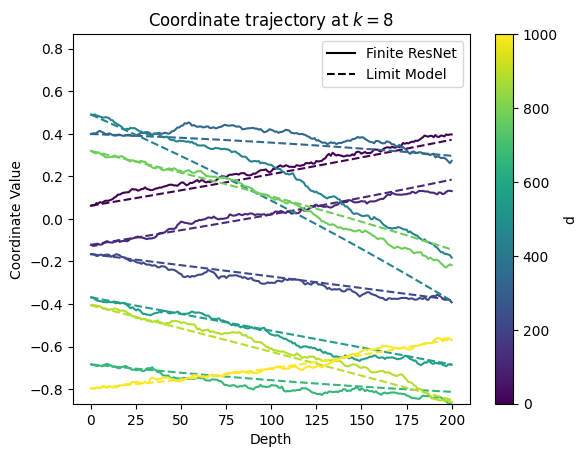

In [17]:
fig1h = plot_trajectory(h_ds, H_ds, train_iter=plot_k, n_coords=10)
plt.savefig("plots/coord_trajectory_h.pdf", bbox_inches="tight")
plt.show()


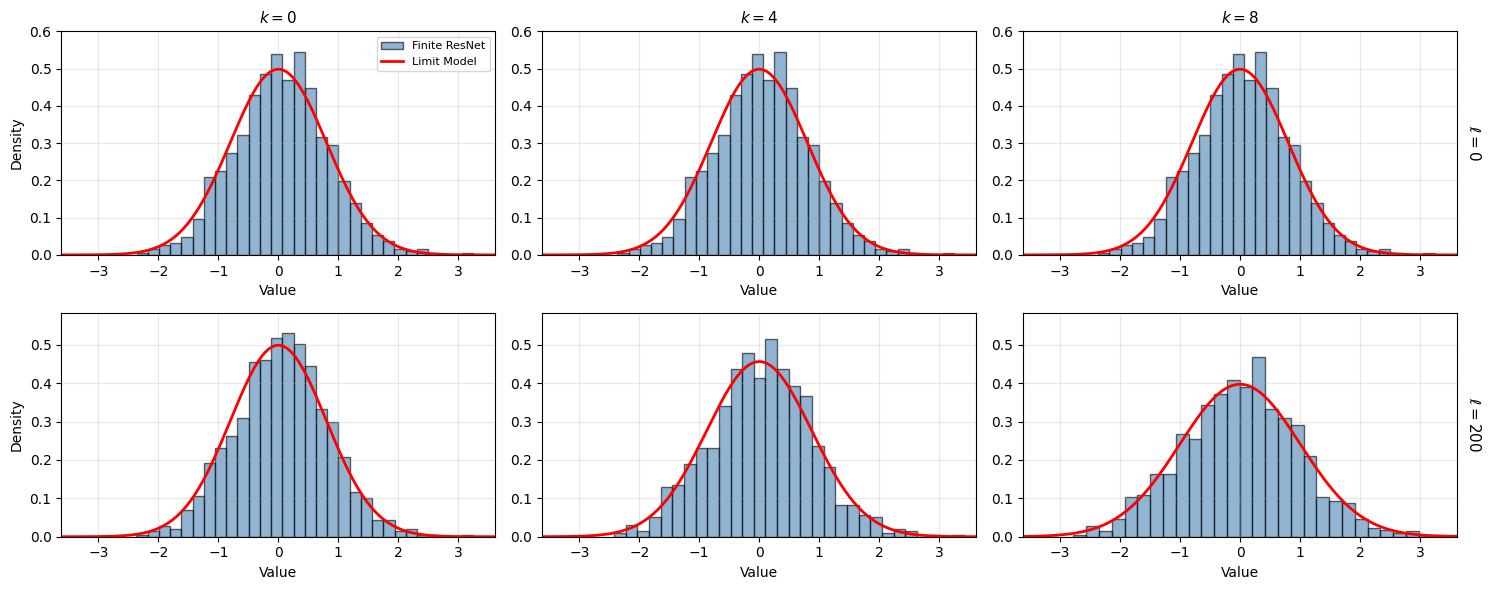

In [18]:
fig2h = plot_time_slices(hs, std_H, 
                        iteration_indices=[0, plot_k//2, plot_k],
                        time_slices=[0, std_H.shape[1]-1])
plt.savefig("plots/coord_histogram_h.pdf", bbox_inches="tight")
plt.show()

### Backward Pass

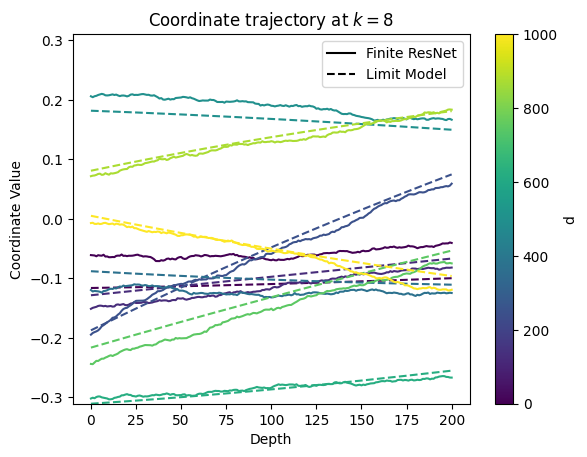

In [19]:
fig1b = plot_trajectory(D*b_ds, B_ds, train_iter=plot_k, n_coords=9)
plt.savefig("plots/coord_trajectory_b.pdf", bbox_inches="tight")
plt.show()

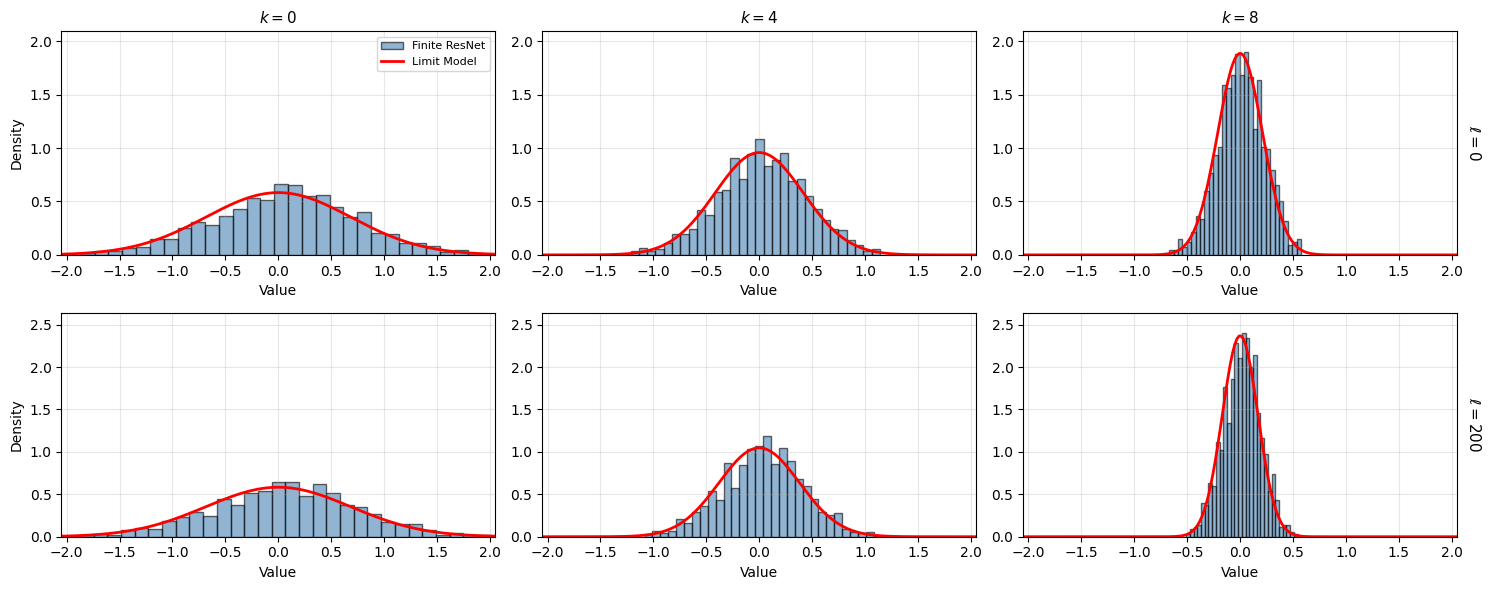

In [20]:
fig2b = plot_time_slices(D*bs, std_B, 
                        iteration_indices=[0, plot_k//2, plot_k],
                        time_slices=[0, std_B.shape[1]-1])
plt.savefig("plots/coord_histogram_b.pdf", bbox_inches="tight")
plt.show()